In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx, serialization
import optax

from typing import Callable
from abc import ABC, abstractmethod
from time import time
import matplotlib.pyplot as plt

from fmmax import basis, fmm, fields, scattering
import refractiveindex2 as ri

In [2]:
jax.config.update("jax_default_matmul_precision", "float32")

## Simulation function

In [3]:
SIO2 = ri.RefractiveIndexMaterial(shelf="main", book="SiO2", page="Malitson")
SI3N4 = ri.RefractiveIndexMaterial(shelf="main", book="Si3N4", page="Luke")


def prepare_lens_scattering_solver(
        wavelength: float,
        period: float,
        lens_thickness: float,
        substrate_thickness: float,
        approximate_number_of_terms: int,
        propagate_by_distance: float = 0.
):
    lens_permittivity = SI3N4.get_refractive_index(wavelength_um=wavelength / 1000) ** 2
    permittivity_substrate = SIO2.get_refractive_index(wavelength_um=wavelength / 1000) ** 2

    primitive_lattice_vectors = basis.LatticeVectors(
        u=period * basis.X, v=period * basis.Y
    )
    expansion = basis.generate_expansion(
        primitive_lattice_vectors=primitive_lattice_vectors,
        approximate_num_terms=approximate_number_of_terms,
        truncation=basis.Truncation.CIRCULAR,
    )

    basis_indices_norm = np.linalg.norm(expansion.basis_coefficients, axis=-1)
    n_propagating_waves = np.count_nonzero(basis_indices_norm < period / wavelength)

    in_plane_wavevector = jnp.array([0., 0.])
    solve_result_ambient = fmm.eigensolve_isotropic_media(
        permittivity=jnp.atleast_2d(1.),
        wavelength=jnp.asarray(wavelength),
        in_plane_wavevector=in_plane_wavevector,
        primitive_lattice_vectors=primitive_lattice_vectors,
        expansion=expansion,
        formulation=fmm.Formulation.FFT
    )
    solve_result_substrate = fmm.eigensolve_isotropic_media(
        permittivity=jnp.atleast_2d(permittivity_substrate),
        wavelength=jnp.asarray(wavelength),
        in_plane_wavevector=in_plane_wavevector,
        primitive_lattice_vectors=primitive_lattice_vectors,
        expansion=expansion,
        formulation=fmm.Formulation.FFT
    )
    inc_fwd_amplitude = jnp.zeros(2 * len(expansion.basis_coefficients))
    zero_mode_index, = jnp.where(jnp.all(expansion.basis_coefficients == 0, axis=1))
    inc_fwd_amplitude = inc_fwd_amplitude.at[zero_mode_index].set(1.)
    fwd_amplitude = jnp.asarray(inc_fwd_amplitude[..., jnp.newaxis], dtype=float)

    def lens_pattern_to_scattered_amps_func(lens_pattern: jnp.ndarray) -> jnp.ndarray:
        lens_permittivity_pattern = lens_pattern * (lens_permittivity - 1.) + 1.
        solve_result_crystal = fmm.eigensolve_isotropic_media(
            permittivity=lens_permittivity_pattern,
            wavelength=jnp.asarray(wavelength),
            in_plane_wavevector=in_plane_wavevector,
            primitive_lattice_vectors=primitive_lattice_vectors,
            expansion=expansion,
            formulation=fmm.Formulation.FFT
        )
        s_matrices_interior = scattering.stack_s_matrices_interior(
            layer_solve_results=[
                solve_result_ambient, solve_result_substrate, solve_result_crystal, solve_result_ambient],
            layer_thicknesses=[0., substrate_thickness, lens_thickness, 0.]  # type: ignore[arg-type]
        )
        amplitudes_interior = fields.stack_amplitudes_interior(
            s_matrices_interior=s_matrices_interior,
            forward_amplitude_0_start=jnp.zeros_like(fwd_amplitude),
            backward_amplitude_N_end=fwd_amplitude,
        )
        _, trans_amps = amplitudes_interior[0]

        if propagate_by_distance != 0:
            trans_amps = fields.propagate_amplitude(
                amplitude=trans_amps,
                distance=propagate_by_distance,  # type: ignore[arg-type]
                layer_solve_result=solve_result_ambient
            )

        te, th = fields.fields_from_wave_amplitudes(
            forward_amplitude=jnp.zeros_like(trans_amps),
            backward_amplitude=trans_amps,
            layer_solve_result=solve_result_ambient
        )
        trans_e_x, trans_e_y, _ = te
        propagating_trans_e_x_amps = trans_e_x[:n_propagating_waves].flatten()
        propagating_trans_e_y_amps = trans_e_y[:n_propagating_waves].flatten()

        ref_amps, _ = amplitudes_interior[-1]
        re, rh = fields.fields_from_wave_amplitudes(
            forward_amplitude=ref_amps,
            backward_amplitude=jnp.zeros_like(ref_amps),
            layer_solve_result=solve_result_ambient
        )
        return jnp.array([
            (te[0].squeeze()[:n_propagating_waves], te[1].squeeze()[:n_propagating_waves]),
            (re[0].squeeze()[:n_propagating_waves], re[1].squeeze()[:n_propagating_waves]),
        ])

        return propagating_trans_e_y_amps

    return lens_pattern_to_scattered_amps_func, expansion.basis_coefficients[:n_propagating_waves]

## Topology parametrization

In [4]:
class TopologyParametrization(ABC):
    def __init__(self, n_geometrical_parameters: int, minval=-1., maxval=1.):
        self.n_geometrical_parameters = n_geometrical_parameters
        self.minval = minval
        self.maxval = maxval

    def apply_symmetry(self, geometrical_parameters: jnp.ndarray) -> jnp.ndarray:
        return geometrical_parameters

    def extract_unique_parameters(self, full_geometrical_parameters: jnp.ndarray) -> jnp.ndarray:
        return full_geometrical_parameters

    @abstractmethod
    def _generate_filling_map(self, geometrical_parameters: jnp.ndarray, n_samples: int) -> jnp.ndarray:
        pass

    def __call__(self, args: jnp.ndarray, n_samples: int = 100, **kwargs):
        geometrical_parameters = self.apply_symmetry(args)
        filling_map = self._generate_filling_map(geometrical_parameters, n_samples, **kwargs)
        return filling_map


class Grid(TopologyParametrization):
    def __init__(self, grid_size: int, symmetry_type: str | None = None):
        if symmetry_type is None:
            unique_ids = np.arange(grid_size ** 2).reshape(grid_size, grid_size)
        elif symmetry_type == 'main_diagonal':
            big_enough_order_factor = 10 ** len(str(grid_size))
            i, j = np.indices((grid_size, grid_size))
            unique_ids = np.max([i, j], axis=0) * big_enough_order_factor + np.min([i, j], axis=0)
        elif symmetry_type == 'central':
            big_enough_order_factor = 10 ** (len(str(grid_size)) + 1)
            i, j = np.indices((grid_size, grid_size))
            center_i = center_j = grid_size / 2 - 1 / 2
            di = np.abs(i - center_i)
            dj = np.abs(j - center_j)
            unique_ids = np.max([di, dj], axis=0) * big_enough_order_factor + np.min([di, dj], axis=0)
        elif symmetry_type == 'bayer':
            big_enough_order_factor = 10 ** (len(str(grid_size)) + 1)
            ri = rj = grid_size / 4 - 1 / 2
            bi = bj = 3 * grid_size / 4 - 1 / 2
            i, j = np.indices((grid_size, grid_size))

            di = np.minimum(np.abs(i - ri), np.abs(i - ri - grid_size))
            dj = np.minimum(np.abs(j - rj), np.abs(j - rj - grid_size))
            unique_ids = np.maximum(di, dj) * big_enough_order_factor + np.minimum(di, dj)
            unique_ids *= big_enough_order_factor ** 2

            di = np.minimum(np.abs(i - bi), np.abs(i - bi + grid_size))
            dj = np.minimum(np.abs(j - bj), np.abs(j - bj + grid_size))
            unique_ids += np.maximum(di, dj) * big_enough_order_factor + np.minimum(di, dj)
        else:
            raise ValueError("Unknown symmetry type. Allowed values: None, 'main_diagonal', 'central', 'bayer'")

        _, unique_parameter_indices, symmetry_indices = np.unique(unique_ids, return_index=True, return_inverse=True)

        self.grid_size = grid_size
        self.symmetry_indices = jnp.array(symmetry_indices)
        self.unique_parameter_indices = unique_parameter_indices
        n_geometrical_parameters = len(unique_parameter_indices)
        TopologyParametrization.__init__(self, n_geometrical_parameters)

    def apply_symmetry(self, geometrical_parameters: jnp.ndarray) -> jnp.ndarray:
        return geometrical_parameters[self.symmetry_indices]

    def extract_unique_parameters(self, full_geometrical_parameters: jnp.ndarray) -> jnp.ndarray:
        return full_geometrical_parameters[self.unique_parameter_indices]


class CylindricalPillar(Grid):
    def __init__(self, grid_size: int, symmetry_type: str | None = None):
        Grid.__init__(self, grid_size, symmetry_type)
        self.minval = 0

    @staticmethod
    def _circle_filling(relative_diameter, n_samples):
        relative_radius = relative_diameter / 4
        x = jnp.linspace(0, 1, n_samples)
        x, y = jnp.meshgrid(x, x)
        r = (x - 0.5) ** 2 + (y - 0.5) ** 2
        filling = (relative_radius - r) * n_samples
        return jnp.clip(filling, 0, 1)

    def _generate_filling_map(self, geometrical_parameters: jnp.ndarray, n_samples: int) -> jnp.ndarray:
        n_pixels_per_pillar = round(n_samples / self.grid_size)
        geometrical_parameters = geometrical_parameters.flatten()
        filling_blocks_flat = jax.vmap(
            CylindricalPillar._circle_filling,
            in_axes=(0, None)
        )(
            geometrical_parameters, n_pixels_per_pillar
        )
        filling_blocks = filling_blocks_flat.reshape(
            self.grid_size, self.grid_size, n_pixels_per_pillar, n_pixels_per_pillar
        )
        filling = filling_blocks.transpose(0, 2, 1, 3).reshape(
            self.grid_size * n_pixels_per_pillar, self.grid_size * n_pixels_per_pillar
        )
        filling = jax.image.resize(filling, shape=(n_samples, n_samples), method='linear')
        return filling

## Generate lens geometries

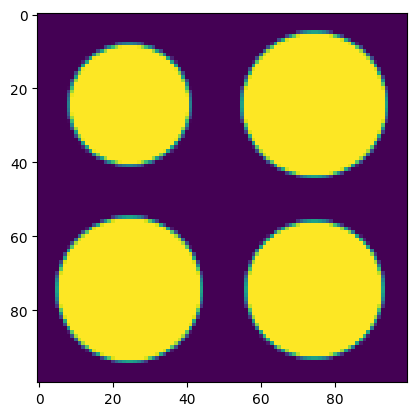

In [5]:
topology = CylindricalPillar(2, 'bayer')

test_pattern = topology(jax.random.uniform(jax.random.key(42), topology.n_geometrical_parameters))
plt.imshow(test_pattern)
plt.show()

In [9]:
n_samples = 2 ** 12
key_seed = 1
geometrical_parameters = jax.random.uniform(jax.random.key(key_seed), (n_samples, topology.n_geometrical_parameters))
print(geometrical_parameters.shape)

(4096, 3)


## Prepare simulation function and parameters

In [7]:
sim_f_r, expansion_r = prepare_lens_scattering_solver(
    wavelength=650,
    period=2000,
    lens_thickness=600,
    substrate_thickness=500,
    approximate_number_of_terms=600,
)
sim_f_r_jit = jax.jit(sim_f_r)
n_propagating_r = len(expansion_r)

sim_f_g, expansion_g = prepare_lens_scattering_solver(
    wavelength=550,
    period=2000,
    lens_thickness=600,
    substrate_thickness=500,
    approximate_number_of_terms=600,
)
sim_f_g_jit = jax.jit(sim_f_g)
n_propagating_g = len(expansion_g)

sim_f_b, expansion_b = prepare_lens_scattering_solver(
    wavelength=450,
    period=2000,
    lens_thickness=600,
    substrate_thickness=500,
    approximate_number_of_terms=600,
)
sim_f_b_jit = jax.jit(sim_f_b)
n_propagating_b = len(expansion_b)

In [8]:
n_propagating_r, n_propagating_g, n_propagating_b

(29, 45, 61)

## Simulate all lenses in the training set

In [10]:
amps_r = []
amps_g = []
amps_b = []

for i in range(n_samples):
    start = time()
    pattern = topology(geometrical_parameters[i])
    amps_r.append(sim_f_r_jit(pattern))
    amps_g.append(sim_f_g_jit(pattern))
    amps_b.append(sim_f_b_jit(pattern))
    if i % 10 == 0:
        print(i, time() - start)

amps_r = np.array(amps_r)
amps_g= np.array(amps_g)
amps_b = np.array(amps_b)
np.savez(f'rgb_cylindrical_batch{key_seed}.npz', params=geometrical_parameters, amps_r=amps_r, amps_g=amps_g, amps_b=amps_b)

E0201 13:59:57.079189   16040 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %dot_general.80 = c64[1186,1186]{1,0} dot(%constant.196, %constant.197), lhs_contracting_dims={1}, rhs_contracting_dims={0}, operand_precision={highest,highest}, metadata={op_name="jit(lens_pattern_to_scattered_amps_func)/dot_general" stack_frame_id=9}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0201 14:00:12.489315   13907 slow_operation_alarm.cc:140] The operation took 16.410270067s
Constant folding an instruction is taking > 1s:

  %dot_general.80 = c64[1186,1186]{1,0} dot(%constant.196, %constant.197), lhs_contracting_dims=

0 378.13502645492554
10 1.0783064365386963
20 1.0628535747528076
30 1.0778000354766846
40 1.0908548831939697
50 1.0691397190093994
60 1.0904133319854736
70 1.0960845947265625
80 1.0912225246429443
90 1.0965313911437988
100 1.0882594585418701
110 1.1139822006225586
120 1.0907444953918457
130 1.0794165134429932
140 1.0888617038726807
150 1.0912623405456543
160 1.084764003753662
170 1.101900339126587
180 1.074718952178955
190 1.099125862121582
200 1.0772337913513184
210 1.0866730213165283
220 1.069486379623413
230 1.092036247253418
240 1.1422631740570068
250 1.0848114490509033
260 1.0978755950927734
270 1.0889246463775635
280 1.0864665508270264
290 1.0807456970214844
300 1.097224473953247
310 1.0872037410736084
320 1.0903337001800537
330 1.0769555568695068
340 1.0843274593353271
350 1.085545301437378
360 1.0627338886260986
370 1.0935449600219727
380 1.0784955024719238
390 1.085141897201538
400 1.067248821258545
410 1.0873374938964844
420 1.1031215190887451
430 1.0885071754455566
440 1.098

In [11]:
print(np.load(f'rgb_cylindrical_batch{key_seed}.npz')['params'].shape)
print(np.load(f'rgb_cylindrical_batch{key_seed}.npz')['amps_r'].shape)
print(np.load(f'rgb_cylindrical_batch{key_seed}.npz')['amps_g'].shape)
print(np.load(f'rgb_cylindrical_batch{key_seed}.npz')['amps_b'].shape)

(4096, 3)
(4096, 2, 2, 29)
(4096, 2, 2, 45)
(4096, 2, 2, 61)
